<a href="https://colab.research.google.com/github/Khushigupta990/Student-Survey/blob/main/AI%26DS_PR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from google.colab import files
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [ ]:
print("📂 A file picker will appear below. Click it and select your CSV file.")
uploaded = files.upload()

# Auto-detect the uploaded filename
import io
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\n✅ File loaded: {filename}")
print(f"📊 Rows: {len(df_raw)}  |  Columns: {df_raw.shape[1]}")
print("\n📋 Your column names are:")
for i, col in enumerate(df_raw.columns):
    print(f"  [{i}] {col}")

📂 A file picker will appear below. Click it and select your CSV file.


Saving student_responses - Form Responses 1 (1).csv to student_responses - Form Responses 1 (1).csv

✅ File loaded: student_responses - Form Responses 1 (1).csv
📊 Rows: 30  |  Columns: 10

📋 Your column names are:
  [0] Timestamp
  [1] 1. What is your favorite learning method? 
  [2] 2. Which device do you use most for studying?
  [3] 3. What is your current semester/year?
  [4] 5 . How satisfied are you with your current studies?
  [5] 6. How motivated do you feel to study daily?
  [6] 7. How many hours do you study per day ?
  [7] 8. How many subjects are you currently enrolled in?
  [8] Column 8
  [9] Column 9


In [ ]:
COL_TIMESTAMP ="Timestamp"
COL_METHOD   = "1. What is your favorite learning method?"
COL_DEVICE   = "2. Which device do you use most for studying?"
COL_SEMESTER = "3. What is your current semester/year?"
COL_SATISF   = "5 . How satisfied are you with your current studies?"
COL_MOTIV    = "6. How motivated do you feel to study daily?"
COL_HOURS    = "7. How many hours do you study per day ?"
COL_SUBJECTS = "8. How many subjects are you currently enrolled in?"
COL_8 = "Column 8"
COL_9 = "Column 9"

# ── Auto-fix: strip extra spaces from all column names ──
df_raw.columns = df_raw.columns.str.strip()

# ── Check which columns exist ──
all_cols = {
    "Timestamp":       COL_TIMESTAMP,
    "Learning Method": COL_METHOD,
    "Device":          COL_DEVICE,
    "Semester":        COL_SEMESTER,
    "Satisfaction":    COL_SATISF,
    "Motivation":      COL_MOTIV,
    "Study Hours":     COL_HOURS,
    "Subjects":        COL_SUBJECTS,
    "Column 8":        COL_8,
    "Column 9":        COL_9,
}
print("\n🔍 Column Check:")
missing = []
for label, col in all_cols.items():
    found = col in df_raw.columns
    status = "✅" if found else "❌ NOT FOUND"
    print(f"  {status}  {label}: '{col}'")
    if not found:
        missing.append((label, col))

if missing:
    print("\n⚠️  Fix the column names above for the ❌ ones, then re-run this cell.")
else:
    print("\n✅ All columns found! Proceed to the next cell.")

# ── Numeric coercion ──
for col in [COL_SATISF, COL_MOTIV, COL_HOURS, COL_SUBJECTS]:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

df = df_raw.copy()



🔍 Column Check:
  ✅  Timestamp: 'Timestamp'
  ✅  Learning Method: '1. What is your favorite learning method?'
  ✅  Device: '2. Which device do you use most for studying?'
  ✅  Semester: '3. What is your current semester/year?'
  ✅  Satisfaction: '5 . How satisfied are you with your current studies?'
  ✅  Motivation: '6. How motivated do you feel to study daily?'
  ✅  Study Hours: '7. How many hours do you study per day ?'
  ✅  Subjects: '8. How many subjects are you currently enrolled in?'
  ✅  Column 8: 'Column 8'
  ✅  Column 9: 'Column 9'

✅ All columns found! Proceed to the next cell.


In [ ]:
TEAL   = ["#1D9E75","#5DCAA5","#9FE1CB","#0F6E56","#04342C"]
PURPLE = ["#7F77DD","#AFA9EC","#534AB7","#3C3489","#EEEDFE"]
AMBER  = ["#EF9F27","#FAC775","#BA7517","#FAEEDA","#633806"]
CORAL  = ["#D85A30","#F0997B","#993C1D","#FAECE7","#4A1B0C"]

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.2,
    "axes.axisbelow":    True,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})

def pct_bar(ax):
    """Add percentage labels on top of bar chart bars."""
    total = sum(p.get_height() for p in ax.patches if p.get_height() > 0)
    if total == 0:
        return
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f"{h/total*100:.1f}%",
                        (p.get_x() + p.get_width()/2, h),
                        ha="center", va="bottom", fontsize=9, color="#444")

def safe_col(df, col):
    """Return series if column exists, else empty series."""
    if col in df.columns:
        return df[col].dropna()
    return pd.Series(dtype=float)

print("✅ Helpers ready!")


✅ Helpers ready!


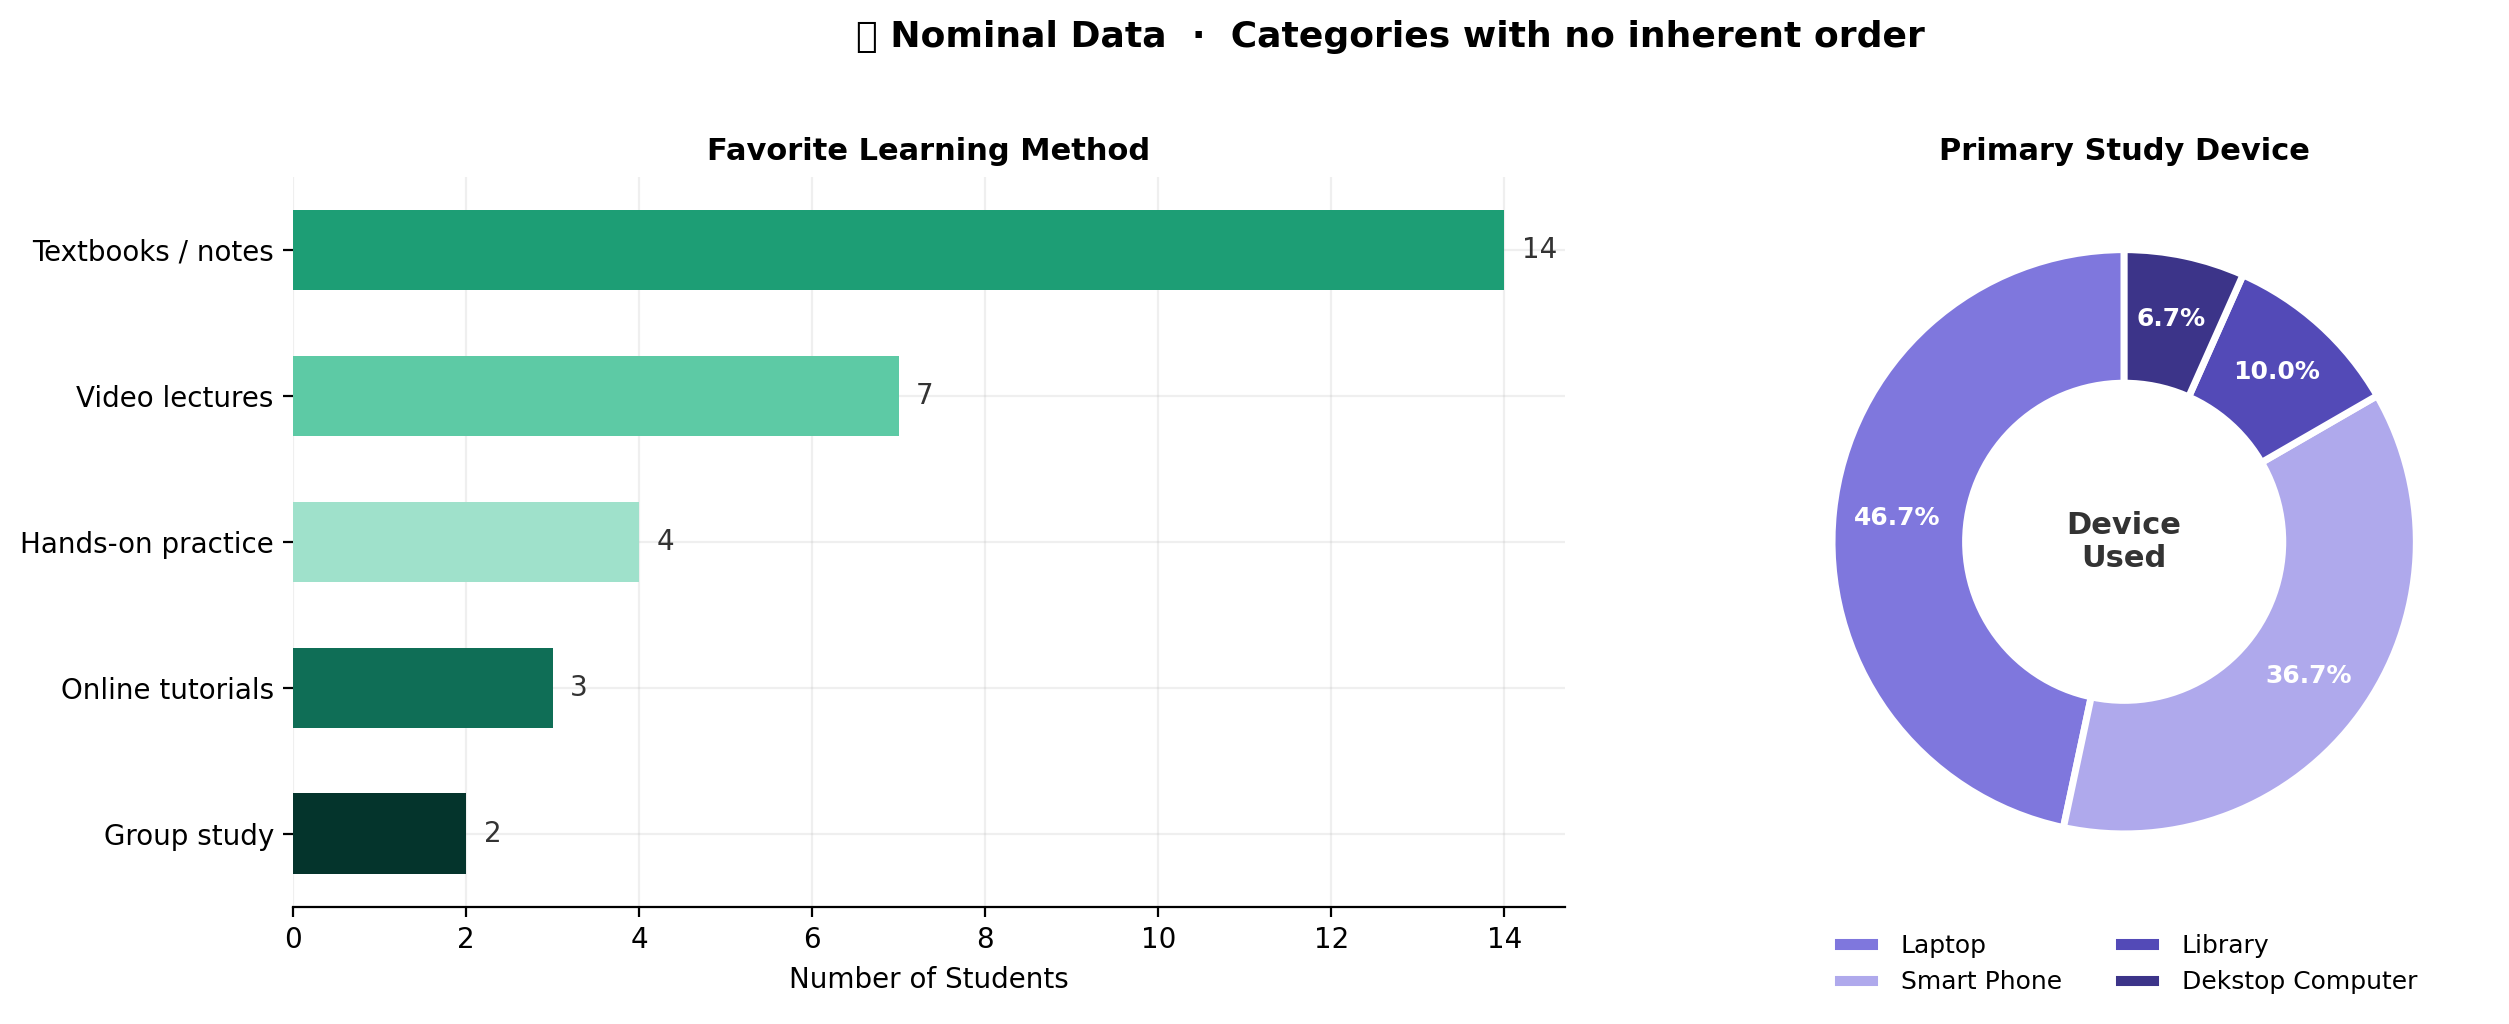

✅ Chart 1 saved: chart1_nominal.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("📌 Nominal Data  ·  Categories with no inherent order",
             fontsize=13, fontweight="bold", y=1.02)

# -- Horizontal Bar: Learning Method --
ax1 = axes[0]
vc = safe_col(df, COL_METHOD).value_counts()
short_names = {
    "Watching video lectures":       "Video lectures",
    "Reading textbooks/notes":       "Textbooks / notes",
    "Group study with friends":      "Group study",
    "Practical / hands-on practice": "Hands-on practice",
    "Online tutorials / courses":    "Online tutorials",
}
vc.index = [short_names.get(i, i[:25]) for i in vc.index]

bars = ax1.barh(vc.index, vc.values,
                color=TEAL[:len(vc)], height=0.55, edgecolor="none")
for bar, val in zip(bars, vc.values):
    ax1.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=10, color="#333")
ax1.invert_yaxis()
ax1.set_xlabel("Number of Students", fontsize=10)
ax1.set_title("Favorite Learning Method", fontsize=11, fontweight="bold")
ax1.spines["left"].set_visible(False)
ax1.grid(axis="x", alpha=0.2)

# -- Donut: Device --
ax2 = axes[1]
vc2 = safe_col(df, COL_DEVICE).value_counts()
wedge_p = {"edgecolor": "white", "linewidth": 2.5}
_, _, autotexts = ax2.pie(
    vc2.values, autopct="%1.1f%%",
    colors=PURPLE[:len(vc2)], wedgeprops=wedge_p,
    startangle=90, pctdistance=0.78)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color("white")
    at.set_fontweight("bold")
centre = plt.Circle((0, 0), 0.55, color="white")
ax2.add_patch(centre)
ax2.text(0, 0, "Device\nUsed", ha="center", va="center",
         fontsize=11, fontweight="bold", color="#333")
ax2.legend(vc2.index, loc="lower center",
           bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=9, frameon=False)
ax2.set_title("Primary Study Device", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("chart1_nominal.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 1 saved: chart1_nominal.png")



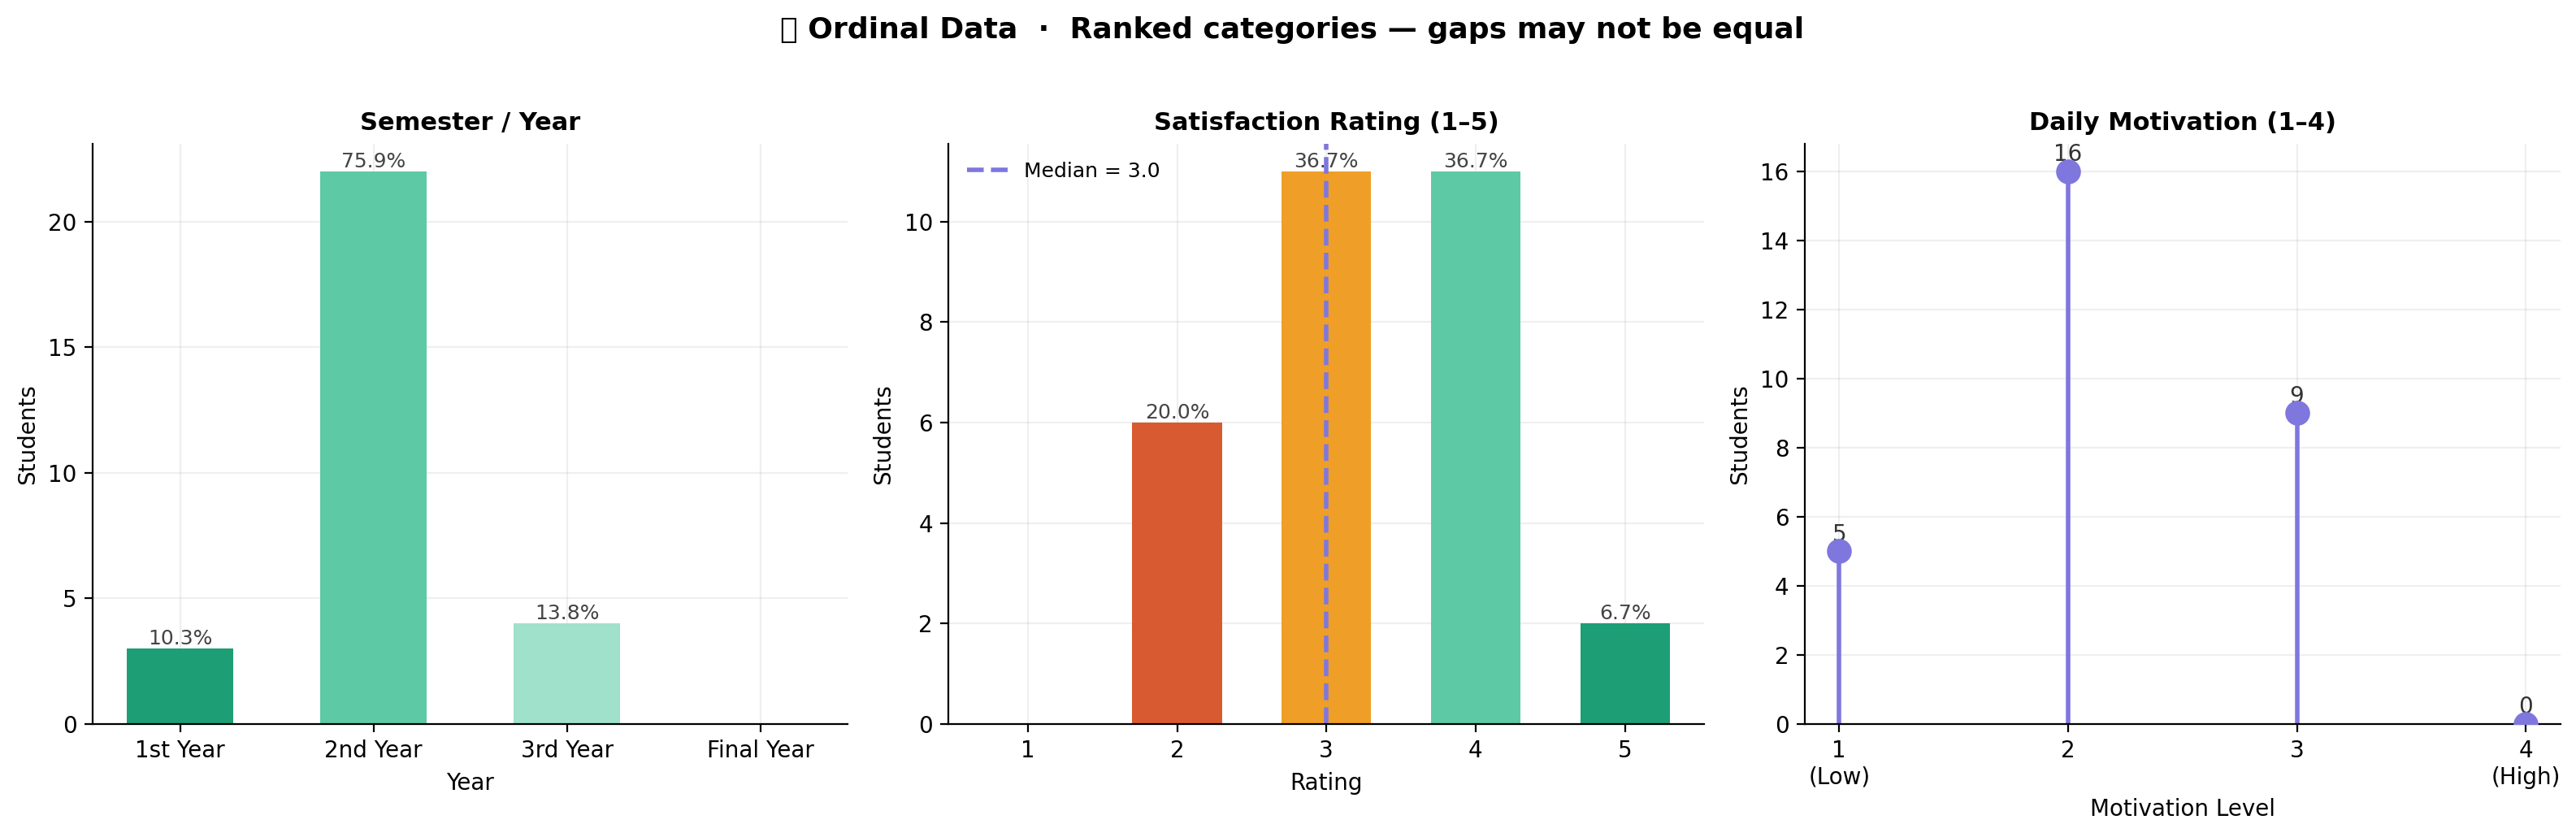

✅ Chart 2 saved: chart2_ordinal.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("📊 Ordinal Data  ·  Ranked categories — gaps may not be equal",
             fontsize=13, fontweight="bold", y=1.02)

# -- Bar: Semester --
ax1 = axes[0]
sem_order = ["First Year / Semester 2","Second Year / Semester 4",
             "Third Year / Semester 6", "Final Year / semester 8"]
sem_short  = ["1st Year", "2nd Year", "3rd Year", "Final Year"]
vc3 = safe_col(df, COL_SEMESTER).value_counts().reindex(sem_order, fill_value=0)
ax1.bar(sem_short, vc3.values,
        color=[TEAL[0], TEAL[1], TEAL[2], TEAL[3]],
        width=0.55, edgecolor="none")
pct_bar(ax1)
ax1.set_title("Semester / Year", fontsize=11, fontweight="bold")
ax1.set_ylabel("Students", fontsize=10)
ax1.set_xlabel("Year", fontsize=10)

# -- Diverging Bar: Satisfaction --
ax2 = axes[1]
sat = safe_col(df, COL_SATISF).value_counts().sort_index()
all_s = pd.Series(0, index=[1,2,3,4,5])
all_s.update(sat)
cols_s = [CORAL[2], CORAL[0], AMBER[0], TEAL[1], TEAL[0]]
ax2.bar(all_s.index.astype(str), all_s.values,
        color=cols_s, width=0.6, edgecolor="none")
pct_bar(ax2)
ax2.set_title("Satisfaction Rating (1–5)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Rating", fontsize=10)
ax2.set_ylabel("Students", fontsize=10)
med_s = safe_col(df, COL_SATISF).median()
ax2.axvline(x=med_s - 1, color=PURPLE[0], linewidth=2,
            linestyle="--", label=f"Median = {med_s:.1f}")
ax2.legend(fontsize=9, frameon=False)

# -- Lollipop: Motivation --
ax3 = axes[2]
mot = safe_col(df, COL_MOTIV).value_counts().sort_index()
all_m = pd.Series(0, index=[1,2,3,4])
all_m.update(mot)
labels_m = ["1\n(Low)", "2", "3", "4\n(High)"]
for i, (lbl, val) in enumerate(zip(labels_m, all_m.values)):
    ax3.plot([lbl, lbl], [0, val], color=PURPLE[0], linewidth=2)
    ax3.scatter([lbl], [val], color=PURPLE[0], s=100, zorder=5)
    ax3.text(i, val + 0.3, str(val), ha="center", fontsize=10, color="#333")
ax3.set_title("Daily Motivation (1–4)", fontsize=11, fontweight="bold")
ax3.set_xlabel("Motivation Level", fontsize=10)
ax3.set_ylabel("Students", fontsize=10)
ax3.set_xticks(range(len(labels_m)))
ax3.set_xticklabels(labels_m)
ax3.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("chart2_ordinal.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 2 saved: chart2_ordinal.png")



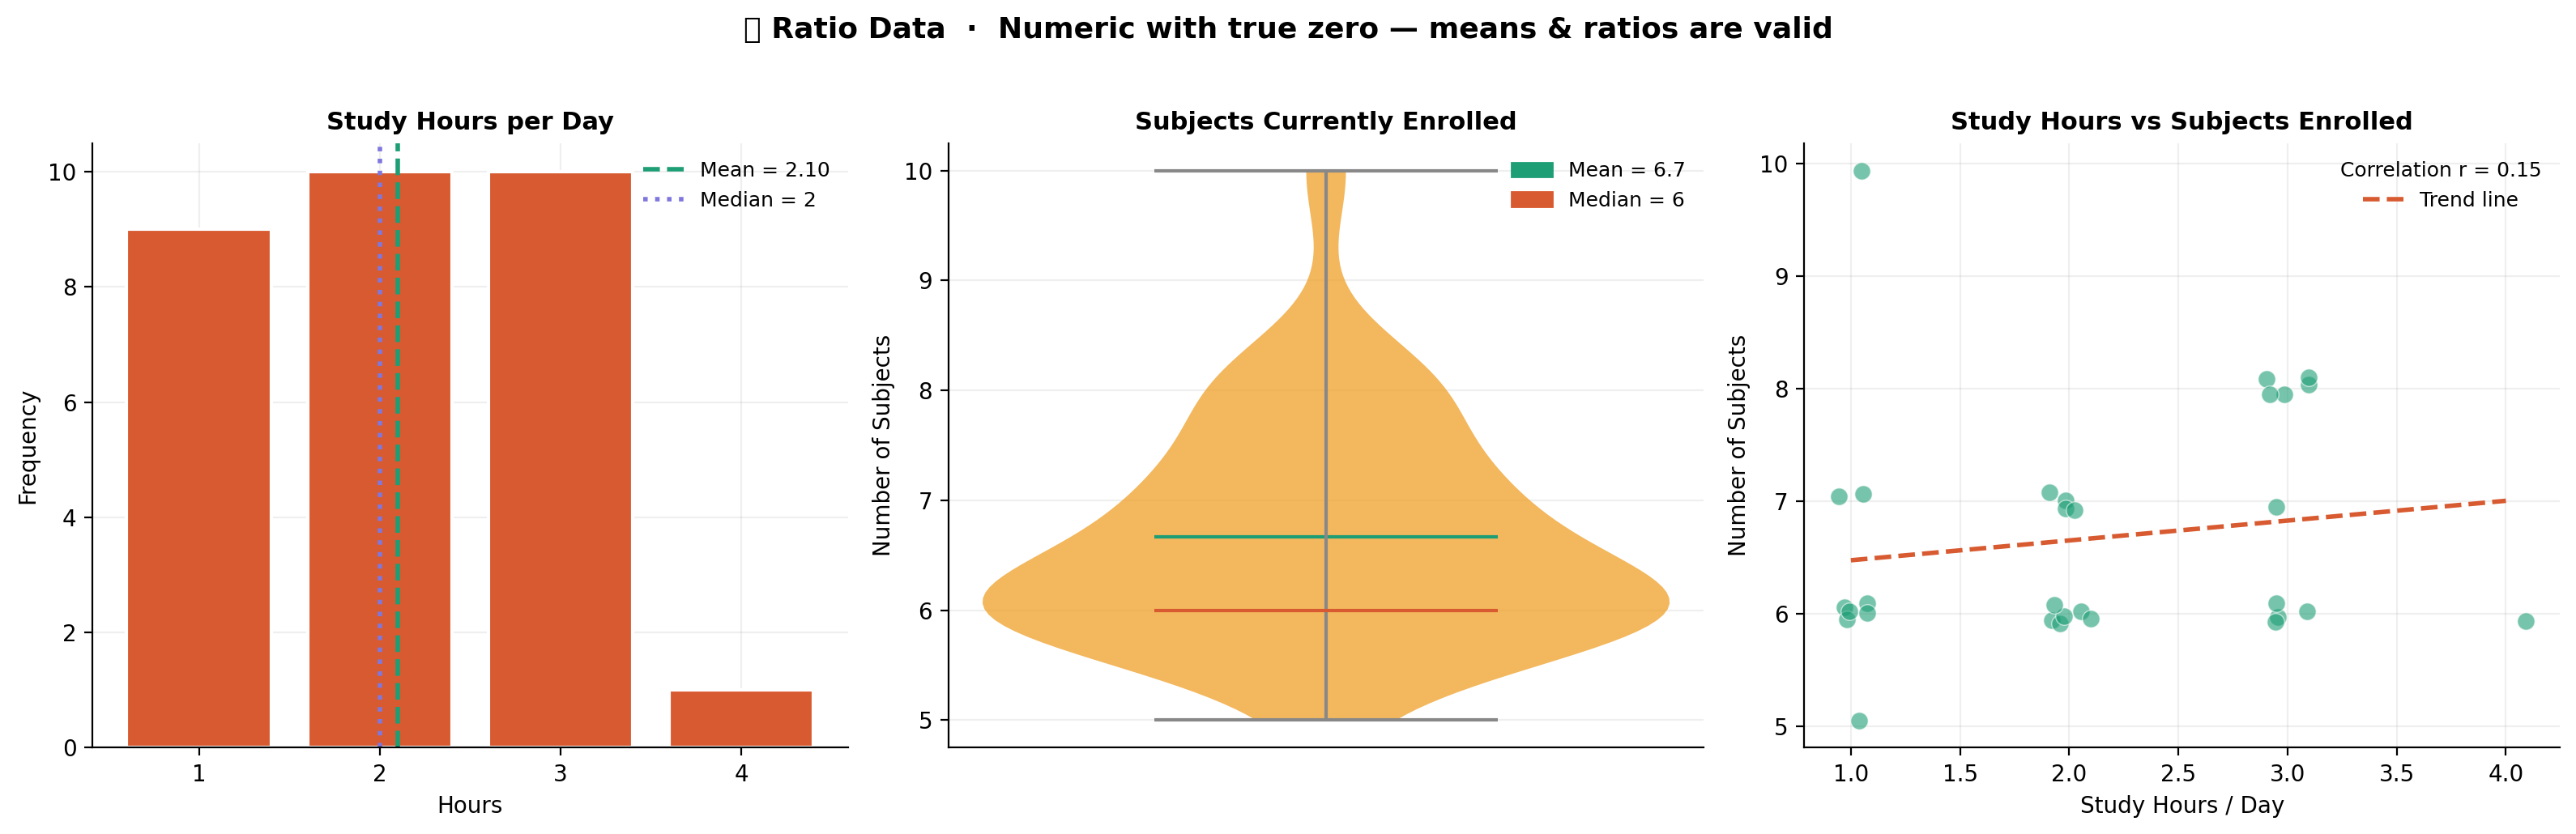

✅ Chart 3 saved: chart3_ratio.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("📈 Ratio Data  ·  Numeric with true zero — means & ratios are valid",
             fontsize=13, fontweight="bold", y=1.02)

# -- Histogram: Study Hours --
ax1 = axes[0]
hrs = safe_col(df, COL_HOURS)
ax1.hist(hrs, bins=[0.5,1.5,2.5,3.5,4.5],
         color=CORAL[0], edgecolor="white", linewidth=1.5, rwidth=0.8)
ax1.set_title("Study Hours per Day", fontsize=11, fontweight="bold")
ax1.set_xlabel("Hours", fontsize=10)
ax1.set_ylabel("Frequency", fontsize=10)
ax1.set_xticks([1,2,3,4])
ax1.axvline(hrs.mean(), color=TEAL[0], linewidth=2,
            linestyle="--", label=f"Mean = {hrs.mean():.2f}")
ax1.axvline(hrs.median(), color=PURPLE[0], linewidth=2,
            linestyle=":", label=f"Median = {hrs.median():.0f}")
ax1.legend(fontsize=9, frameon=False)

# -- Violin: Subjects Enrolled --
ax2 = axes[1]
subj = safe_col(df, COL_SUBJECTS)
if len(subj) > 1:
    parts = ax2.violinplot(subj, positions=[1],
                           showmeans=True, showmedians=True, widths=0.7)
    for pc in parts["bodies"]:
        pc.set_facecolor(AMBER[0])
        pc.set_alpha(0.75)
    parts["cmeans"].set_color(TEAL[0])
    parts["cmedians"].set_color(CORAL[0])
    for key in ["cbars","cmins","cmaxes"]:
        parts[key].set_color("#888")
ax2.set_title("Subjects Currently Enrolled", fontsize=11, fontweight="bold")
ax2.set_ylabel("Number of Subjects", fontsize=10)
ax2.set_xticks([])
legend_p = [
    mpatches.Patch(color=TEAL[0],  label=f"Mean = {subj.mean():.1f}"),
    mpatches.Patch(color=CORAL[0], label=f"Median = {subj.median():.0f}"),
]
ax2.legend(handles=legend_p, fontsize=9, frameon=False)

# -- Scatter: Hours vs Subjects --
ax3 = axes[2]
merged = df[[COL_HOURS, COL_SUBJECTS]].dropna()
if len(merged) > 2:
    jx = merged[COL_HOURS]    + np.random.uniform(-0.1, 0.1, len(merged))
    jy = merged[COL_SUBJECTS] + np.random.uniform(-0.1, 0.1, len(merged))
    ax3.scatter(jx, jy, alpha=0.6, s=60,
                color=TEAL[0], edgecolors="white", linewidths=0.5)
    z = np.polyfit(merged[COL_HOURS], merged[COL_SUBJECTS], 1)
    xs = np.linspace(merged[COL_HOURS].min(), merged[COL_HOURS].max(), 100)
    ax3.plot(xs, np.poly1d(z)(xs), color=CORAL[0],
             linewidth=2, linestyle="--", label="Trend line")
    corr = merged[COL_HOURS].corr(merged[COL_SUBJECTS])
    ax3.legend(fontsize=9, frameon=False,
               title=f"Correlation r = {corr:.2f}", title_fontsize=9)
ax3.set_title("Study Hours vs Subjects Enrolled", fontsize=11, fontweight="bold")
ax3.set_xlabel("Study Hours / Day", fontsize=10)
ax3.set_ylabel("Number of Subjects", fontsize=10)

plt.tight_layout()
plt.savefig("chart3_ratio.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 3 saved: chart3_ratio.png")



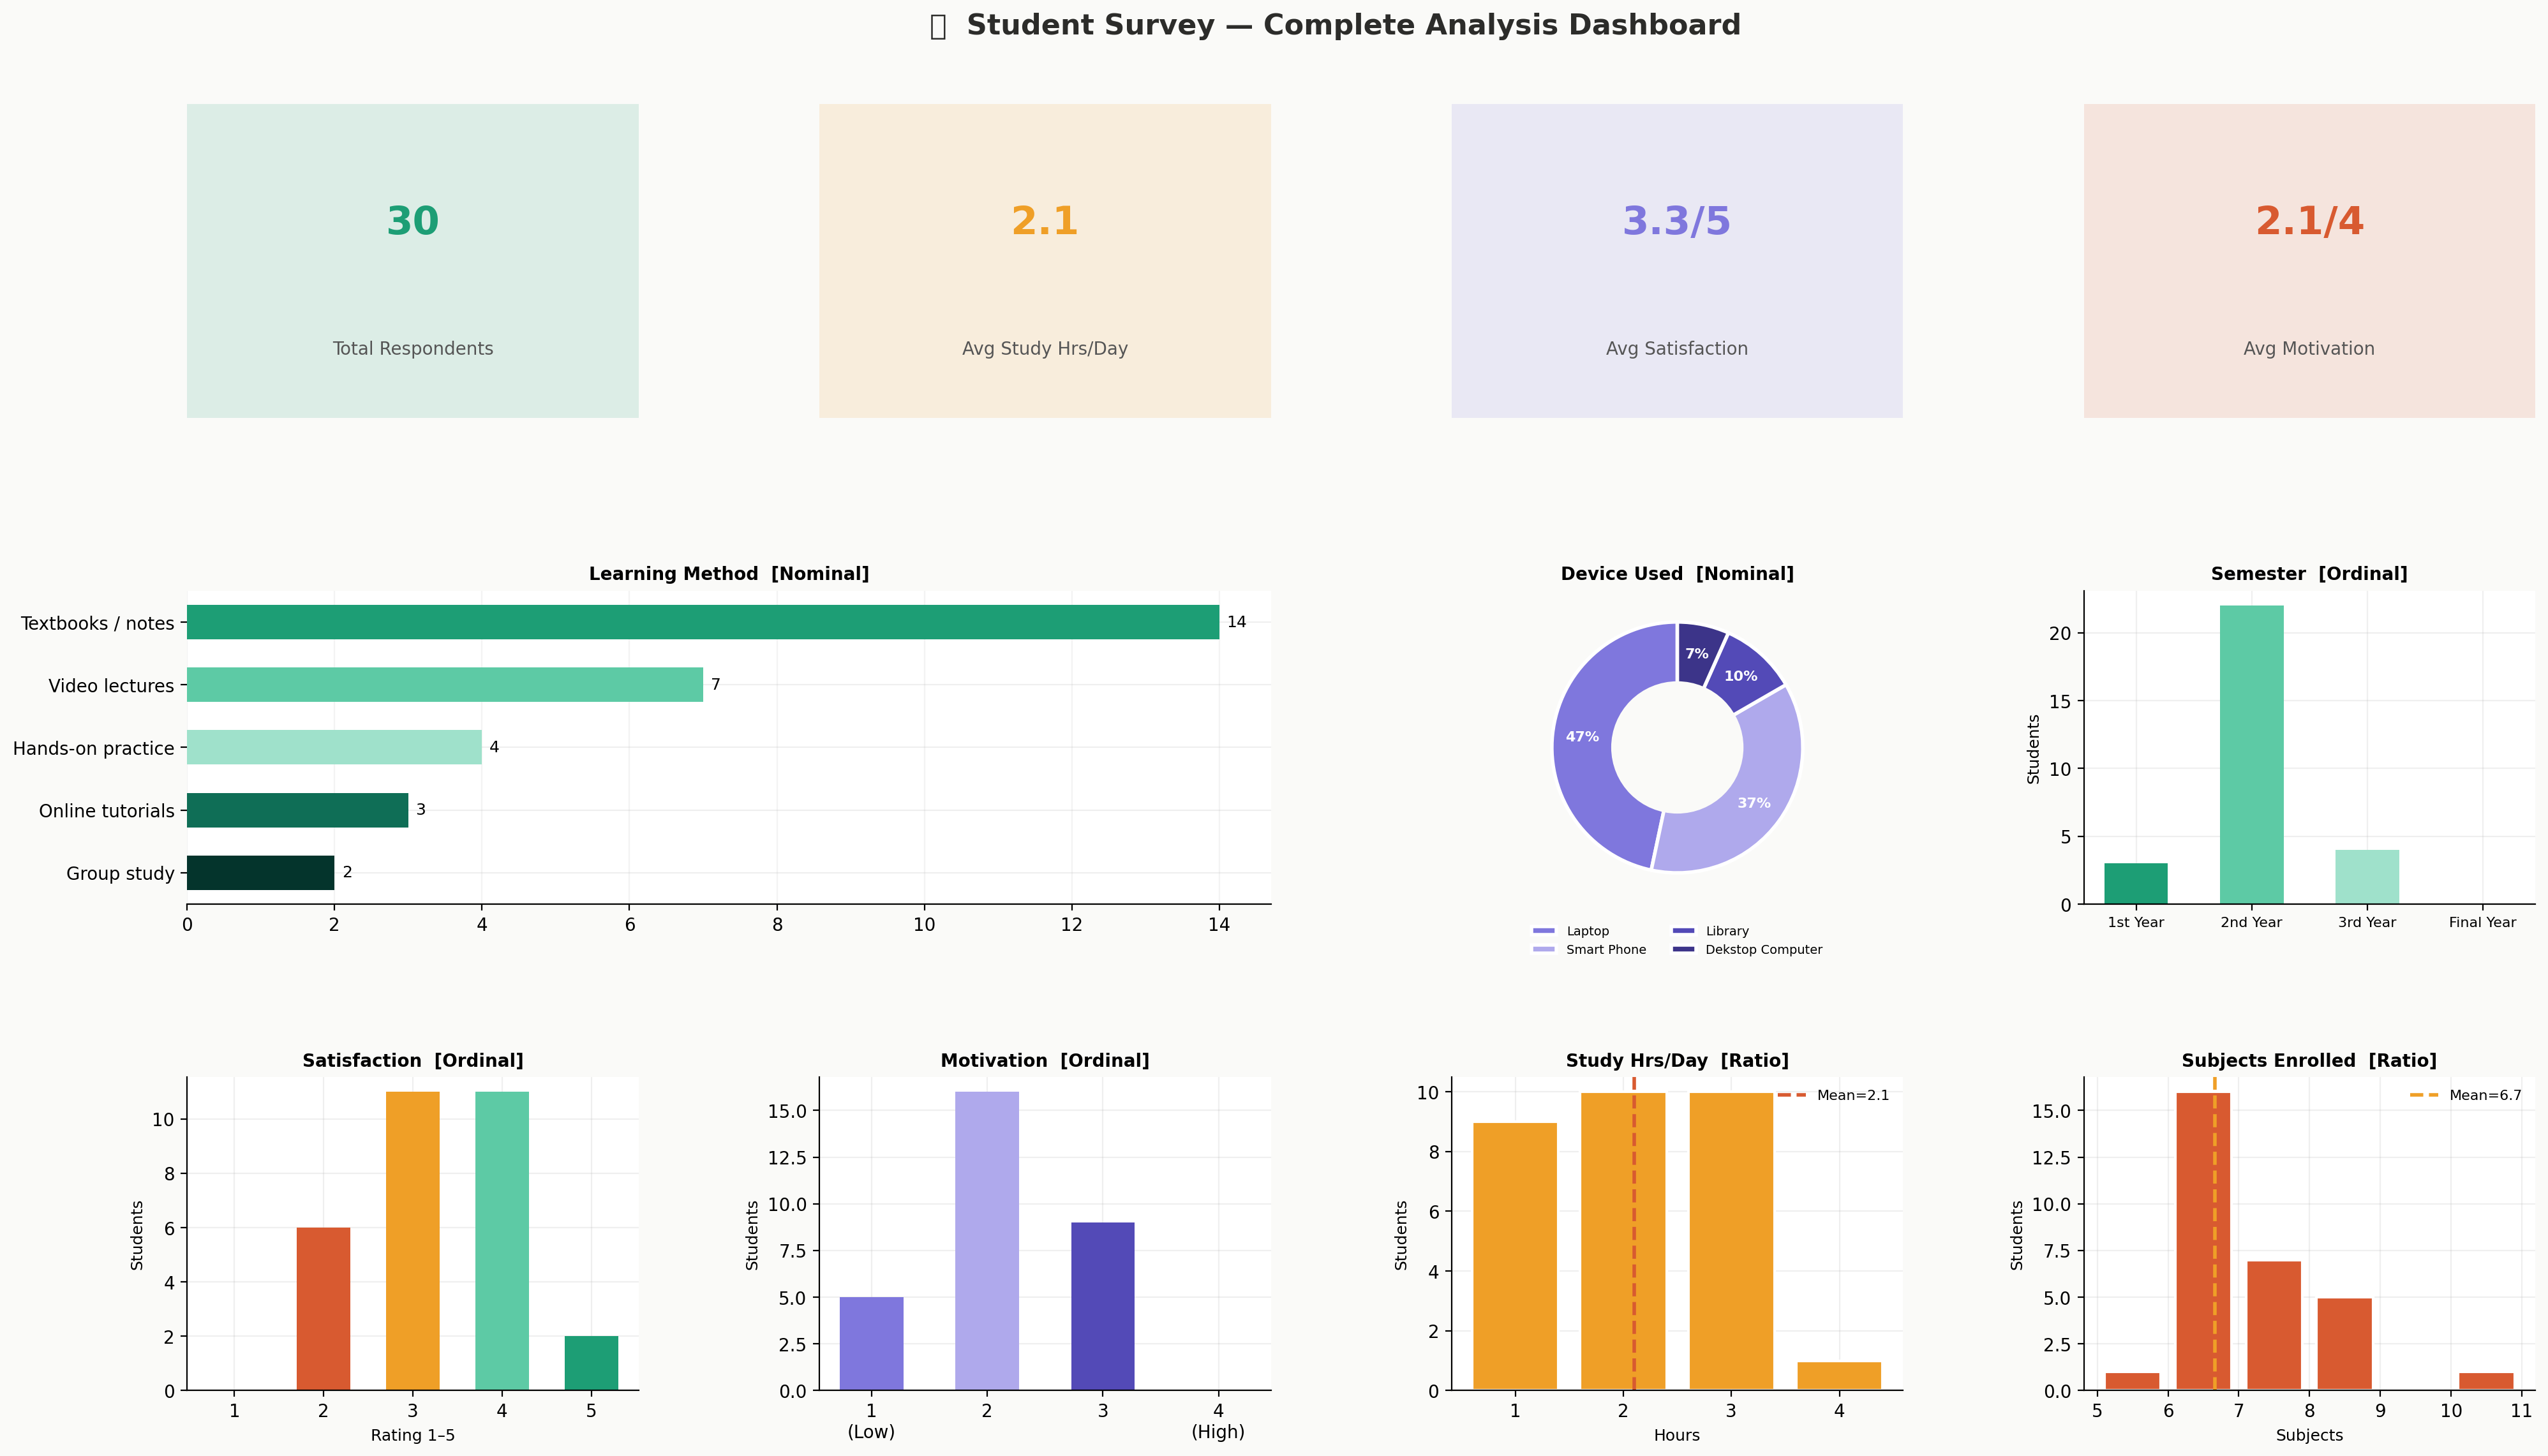

✅ Chart 4 saved: chart4_dashboard.png


In [ ]:
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor("#FAFAF8")
gs = GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4,
              left=0.05, right=0.97, top=0.91, bottom=0.07)

fig.suptitle("🎓  Student Survey — Complete Analysis Dashboard",
             fontsize=16, fontweight="bold", color="#2C2C2A", y=0.97)

# ── Metric Cards (row 0) ──
n       = len(df)
mean_h  = safe_col(df, COL_HOURS).mean()
mean_s  = safe_col(df, COL_SATISF).mean()
mean_m  = safe_col(df, COL_MOTIV).mean()
cards = [
    ("Total Respondents", f"{n}",           TEAL[0]),
    ("Avg Study Hrs/Day", f"{mean_h:.1f}",  AMBER[0]),
    ("Avg Satisfaction",  f"{mean_s:.1f}/5",PURPLE[0]),
    ("Avg Motivation",    f"{mean_m:.1f}/4",CORAL[0]),
]
for i, (lbl, val, col) in enumerate(cards):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(col + "22")
    ax.text(0.5, 0.62, val, transform=ax.transAxes,
            ha="center", va="center", fontsize=22,
            fontweight="bold", color=col)
    ax.text(0.5, 0.22, lbl, transform=ax.transAxes,
            ha="center", va="center", fontsize=10, color="#555")
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])

# ── Row 1 ──
# Learning Method
ax_m = fig.add_subplot(gs[1, :2])
vc = safe_col(df, COL_METHOD).value_counts()
vc.index = [short_names.get(i, i[:25]) for i in vc.index]
ax_m.barh(vc.index, vc.values, color=TEAL[:len(vc)], edgecolor="none", height=0.55)
ax_m.invert_yaxis()
for p in ax_m.patches:
    ax_m.text(p.get_width() + 0.1, p.get_y() + p.get_height()/2,
              str(int(p.get_width())), va="center", fontsize=9)
ax_m.set_title("Learning Method  [Nominal]", fontsize=10, fontweight="bold")
ax_m.spines["left"].set_visible(False)
ax_m.grid(axis="x", alpha=0.15)

# Device Donut
ax_d = fig.add_subplot(gs[1, 2])
vc2 = safe_col(df, COL_DEVICE).value_counts()
_, _, ats = ax_d.pie(vc2.values, autopct="%1.0f%%",
                     colors=PURPLE[:len(vc2)],
                     wedgeprops={"edgecolor":"white","linewidth":2},
                     startangle=90, pctdistance=0.76)
for at in ats:
    at.set_fontsize(8); at.set_color("white"); at.set_fontweight("bold")
ax_d.add_patch(plt.Circle((0,0), 0.52, color="#FAFAF8"))
ax_d.set_title("Device Used  [Nominal]", fontsize=10, fontweight="bold")
ax_d.legend(vc2.index, fontsize=7, loc="lower center",
            bbox_to_anchor=(0.5,-0.2), ncol=2, frameon=False)

# Semester
ax_se = fig.add_subplot(gs[1, 3])
vc3 = safe_col(df, COL_SEMESTER).value_counts().reindex(sem_order, fill_value=0)
ax_se.bar(sem_short, vc3.values,
          color=[TEAL[0],TEAL[1],TEAL[2],TEAL[3]],
          edgecolor="none", width=0.55)
ax_se.set_title("Semester  [Ordinal]", fontsize=10, fontweight="bold")
ax_se.set_ylabel("Students", fontsize=9)
ax_se.tick_params(axis="x", labelsize=8)

# ── Row 2 ──
# Satisfaction
ax_sat = fig.add_subplot(gs[2, 0])
all_s = pd.Series(0, index=[1,2,3,4,5])
all_s.update(safe_col(df, COL_SATISF).value_counts().sort_index())
ax_sat.bar(all_s.index.astype(str), all_s.values,
           color=[CORAL[2],CORAL[0],AMBER[0],TEAL[1],TEAL[0]],
           edgecolor="none", width=0.6)
ax_sat.set_title("Satisfaction  [Ordinal]", fontsize=10, fontweight="bold")
ax_sat.set_xlabel("Rating 1–5", fontsize=9)
ax_sat.set_ylabel("Students", fontsize=9)

# Motivation
ax_mot = fig.add_subplot(gs[2, 1])
all_mv = pd.Series(0, index=[1,2,3,4])
all_mv.update(safe_col(df, COL_MOTIV).value_counts().sort_index())
ax_mot.bar(["1\n(Low)","2","3","4\n(High)"], all_mv.values,
           color=PURPLE[:4], edgecolor="none", width=0.55)
ax_mot.set_title("Motivation  [Ordinal]", fontsize=10, fontweight="bold")
ax_mot.set_ylabel("Students", fontsize=9)

# Study Hours Histogram
ax_hr = fig.add_subplot(gs[2, 2])
hrs2 = safe_col(df, COL_HOURS)
ax_hr.hist(hrs2, bins=[0.5,1.5,2.5,3.5,4.5],
           color=AMBER[0], edgecolor="white", linewidth=1.5, rwidth=0.8)
ax_hr.axvline(hrs2.mean(), color=CORAL[0], linewidth=2,
              linestyle="--", label=f"Mean={hrs2.mean():.1f}")
ax_hr.set_title("Study Hrs/Day  [Ratio]", fontsize=10, fontweight="bold")
ax_hr.set_xlabel("Hours", fontsize=9); ax_hr.set_xticks([1,2,3,4])
ax_hr.set_ylabel("Students", fontsize=9)
ax_hr.legend(fontsize=8, frameon=False)

# Subjects Histogram
ax_sb = fig.add_subplot(gs[2, 3])
subj2 = safe_col(df, COL_SUBJECTS)
bins_s = range(int(subj2.min()), int(subj2.max())+2) if len(subj2) > 0 else 5
ax_sb.hist(subj2, bins=bins_s, color=CORAL[0],
           edgecolor="white", linewidth=1.5, rwidth=0.8)
ax_sb.axvline(subj2.mean(), color=AMBER[0], linewidth=2,
              linestyle="--", label=f"Mean={subj2.mean():.1f}")
ax_sb.set_title("Subjects Enrolled  [Ratio]", fontsize=10, fontweight="bold")
ax_sb.set_xlabel("Subjects", fontsize=9)
ax_sb.set_ylabel("Students", fontsize=9)
ax_sb.legend(fontsize=8, frameon=False)

plt.savefig("chart4_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 4 saved: chart4_dashboard.png")


In [ ]:
print("=" * 60)
print("   DESCRIPTIVE STATISTICS SUMMARY")
print("=" * 60)

print("\n[NOMINAL] Favorite Learning Method")
vc = safe_col(df, COL_METHOD).value_counts()
for k, v in vc.items():
    print(f"  {str(k):<42} {v:>3}  ({v/len(df)*100:.1f}%)")
print(f"  ► Mode: {vc.idxmax()}")

print("\n[NOMINAL] Study Device")
vc2 = safe_col(df, COL_DEVICE).value_counts()
for k, v in vc2.items():
    print(f"  {str(k):<25} {v:>3}  ({v/len(df)*100:.1f}%)")

print("\n[ORDINAL] Semester Distribution")
vc3 = safe_col(df, COL_SEMESTER).value_counts()
for k, v in vc3.items():
    print(f"  {str(k):<35} {v:>3}  ({v/len(df)*100:.1f}%)")

for col, name, dtype in [
    (COL_SATISF, "Satisfaction (1–5)", "ORDINAL"),
    (COL_MOTIV,  "Motivation  (1–4)",  "ORDINAL"),
]:
    s = safe_col(df, col)
    print(f"\n[{dtype}] {name}")
    print(f"  Median  : {s.median()}")
    print(f"  Mode    : {s.mode().iloc[0]}")
    print(f"  IQR     : {s.quantile(0.75) - s.quantile(0.25)}")

for col, name in [(COL_HOURS,"Study Hours/Day"),(COL_SUBJECTS,"Subjects Enrolled")]:
    s = safe_col(df, col)
    print(f"\n[RATIO] {name}")
    print(f"  Mean    : {s.mean():.2f}")
    print(f"  Median  : {s.median():.2f}")
    print(f"  Std Dev : {s.std():.2f}")
    print(f"  Min/Max : {s.min():.0f}  /  {s.max():.0f}")
    print(f"  Range   : {s.max()-s.min():.0f}")

print("\n" + "="*60)
print("✅ Analysis complete!")



   DESCRIPTIVE STATISTICS SUMMARY

[NOMINAL] Favorite Learning Method
  Reading textbooks/notes                     14  (46.7%)
  Watching video lectures                      7  (23.3%)
  Practical / hands-on practice                4  (13.3%)
  Online tutorials / courses                   3  (10.0%)
  Group study with friends                     2  (6.7%)
  ► Mode: Reading textbooks/notes

[NOMINAL] Study Device
  Laptop                     14  (46.7%)
  Smart Phone                11  (36.7%)
  Library                     3  (10.0%)
  Dekstop Computer            2  (6.7%)

[ORDINAL] Semester Distribution
  Second Year / Semester 4             22  (73.3%)
  Third Year / Semester 6               4  (13.3%)
  First Year / Semester 2               3  (10.0%)
  First Year / Semester 2, Second Year / Semester 4   1  (3.3%)

[ORDINAL] Satisfaction (1–5)
  Median  : 3.0
  Mode    : 3
  IQR     : 1.0

[ORDINAL] Motivation  (1–4)
  Median  : 2.0
  Mode    : 2
  IQR     : 1.0

[RATIO] Study Hour

In [ ]:
from google.colab import files as colab_files

for fname in ["chart1_nominal.png","chart2_ordinal.png",
              "chart3_ratio.png","chart4_dashboard.png"]:
    try:
        colab_files.download(fname)
        print(f"⬇️  Downloading {fname}")
    except Exception as e:
        print(f"⚠️  Could not download {fname}: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading chart1_nominal.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇️  Downloading chart3_ratio.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading chart4_dashboard.png
